<a href="https://colab.research.google.com/github/sangamitrap/2048-GAME/blob/main/Cbam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
dataset_path = "/content/drive/MyDrive/banana_leaf_disease"

In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

['PESTAL~1', 'cordana', 'healthy', 'sigatoka']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
def channel_attention(input_feature, ratio=8):

    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1,1,channel))(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1,1,channel))(max_pool)

    shared_dense_one = layers.Dense(
        channel // ratio,
        activation='relu',
        kernel_initializer='he_normal',
        use_bias=True
    )

    shared_dense_two = layers.Dense(
        channel,
        kernel_initializer='he_normal',
        use_bias=True
    )

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    cbam_feature = layers.Add()([avg_out, max_out])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

In [ ]:
def spatial_attention(input_feature):

    avg_pool = tf.reduce_mean(input_feature, axis=3, keepdims=True)
    max_pool = tf.reduce_max(input_feature, axis=3, keepdims=True)

    concat = layers.Concatenate(axis=3)([avg_pool, max_pool])

    cbam_feature = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(concat)

    return layers.Multiply()([input_feature, cbam_feature])

In [ ]:
def cbam_block(feature_map):

    feature_map = channel_attention(feature_map)
    feature_map = spatial_attention(feature_map)

    return feature_map

In [ ]:
base_model = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def spatial_attention(input_feature):

    avg_pool = layers.Lambda(
        lambda x: tf.reduce_mean(x, axis=3, keepdims=True)
    )(input_feature)

    max_pool = layers.Lambda(
        lambda x: tf.reduce_max(x, axis=3, keepdims=True)
    )(input_feature)

    concat = layers.Concatenate(axis=3)(
        [avg_pool, max_pool]
    )

    cbam_feature = layers.Conv2D(
        filters=1,
        kernel_size=7,
        strides=1,
        padding='same',
        activation='sigmoid'
    )(concat)

    return layers.Multiply()(
        [input_feature, cbam_feature]
    )

In [ ]:
dummy = tf.random.normal((1,7,7,960))

out = cbam_block(dummy)

print(out.shape)

(1, 7, 7, 960)


In [ ]:
inputs = layers.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x)

x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 960) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1, 960) │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 1, 120) │    115,320 │ reshape_2[0][0],  │
│                     │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 1, 960) │    116,160 │ dense_2[0][0],    │
│                     │                   │            │ dense_2[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 1, 1, 960) │          0 │ dense_3[0][0],    │
│                     │                   │            │ dense_3[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 1, 1, 960) │          0 │ add_9[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 7, 2)   │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 7, 7, 960) │          0 │ multiply_10[0][0… │
│ (Multiply)          │                   │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_11[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    246,016 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_4[0][0]   

 Total params: 3,474,975 (13.26 MB)

 Trainable params: 478,623 (1.83 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 279s 6s/step - accuracy: 0.7258 - loss: 0.6761 - val_accuracy: 0.9469 - val_loss: 0.1766
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9555 - loss: 0.1370 - val_accuracy: 0.9563 - val_loss: 0.1361
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9805 - loss: 0.0602 - val_accuracy: 0.9625 - val_loss: 0.1203
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9953 - loss: 0.0273 - val_accuracy: 0.9719 - val_loss: 0.1109
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9961 - loss: 0.0164 - val_accuracy: 0.9719 - val_loss: 0.1359
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9992 - loss: 0.0087 - val_accuracy: 0.9688 - val_loss: 0.1198
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9656 - val_loss: 0.1139
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9625 - v

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.9688 - loss: 0.0912 - val_accuracy: 0.9719 - val_loss: 0.1298
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9836 - loss: 0.0533 - val_accuracy: 0.9719 - val_loss: 0.1325
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9859 - loss: 0.0366 - val_accuracy: 0.9719 - val_loss: 0.1342
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9891 - loss: 0.0301 - val_accuracy: 0.9688 - val_loss: 0.1358
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9953 - loss: 0.0231 - val_accuracy: 0.9688 - val_loss: 0.1367
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9969 - loss: 0.0156 - val_accuracy: 0.9688 - val_loss: 0.1364
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9969 - loss: 0.0136 - val_accuracy: 0.9688 - val_loss: 0.1370
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9953 - loss: 0.0157 - val_accuracy: 0.9688 -

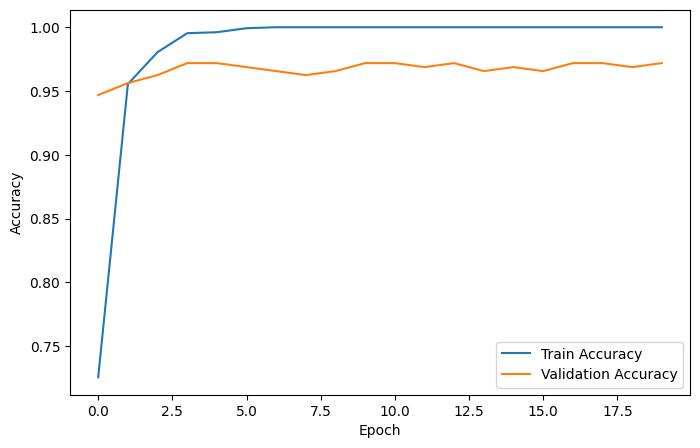

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

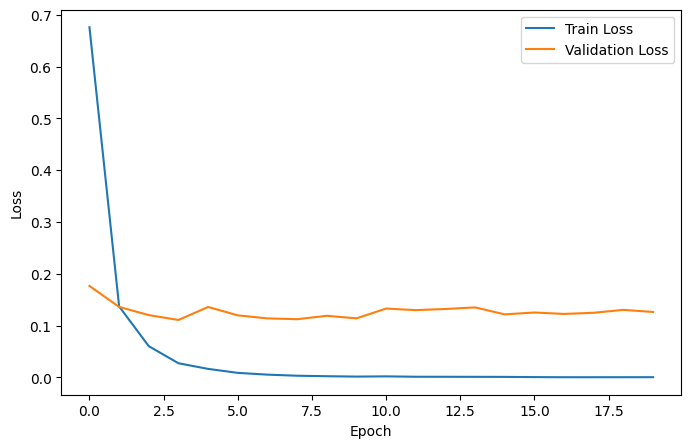

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)

print("Validation Accuracy:", acc)
print("Validation Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9688 - loss: 0.1362
Validation Accuracy: 0.96875
Validation Loss: 0.1361820250749588


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[69  0  1  1]
 [ 0 75  0  2]
 [ 2  0 76  1]
 [ 0  2  1 90]]


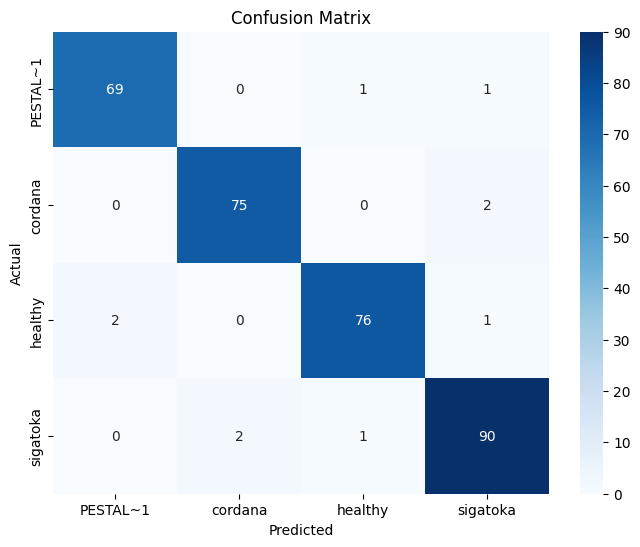

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    PESTAL~1       0.97      0.97      0.97        71
     cordana       0.97      0.97      0.97        77
     healthy       0.97      0.96      0.97        79
    sigatoka       0.96      0.97      0.96        93

    accuracy                           0.97       320
   macro avg       0.97      0.97      0.97       320
weighted avg       0.97      0.97      0.97       320



In [ ]:
model.save("/content/drive/MyDrive/MobileNetV3_CBAM.keras")

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Difference:", train_acc - val_acc)

Train Accuracy: 1.0
Validation Accuracy: 0.971875011920929
Difference: 0.028124988079071045


In [ ]:
x = layers.Dropout(0.5)(x)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [ ]:
tf.keras.optimizers.Adam(1e-5)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.9984 - loss: 0.0115 - val_accuracy: 0.9656 - val_loss: 0.1355 - learning_rate: 1.0000e-05
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9953 - loss: 0.0140 - val_accuracy: 0.9656 - val_loss: 0.1346 - learning_rate: 1.0000e-05
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9656 - val_loss: 0.1337 - learning_rate: 1.0000e-05
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.9961 - loss: 0.0126 - val_accuracy: 0.9719 - val_loss: 0.1339 - learning_rate: 1.0000e-05
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9977 - loss: 0.0095 - val_accuracy: 0.9719 - val_loss: 0.1345 - learning_rate: 1.0000e-05
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9972 - loss: 0.0114
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9977 - l

In [ ]:
loss, acc = model.evaluate(val_ds)

print("Validation Accuracy:", acc)
print("Validation Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9719 - loss: 0.1285
Validation Accuracy: 0.971875011920929
Validation Loss: 0.12849709391593933


In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Difference:", train_acc - val_acc)

Train Accuracy: 0.9984375238418579
Validation Accuracy: 0.971875011920929
Difference: 0.026562511920928955


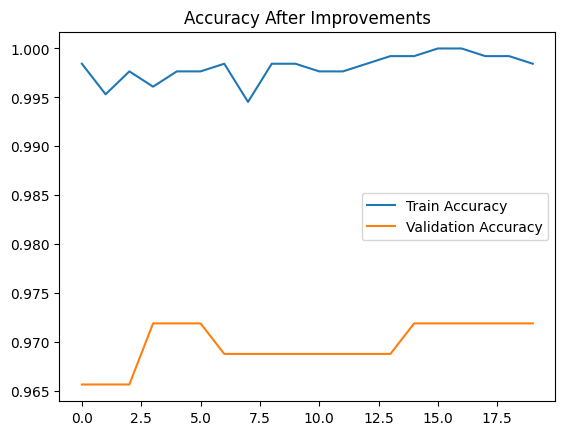

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy After Improvements")
plt.show()

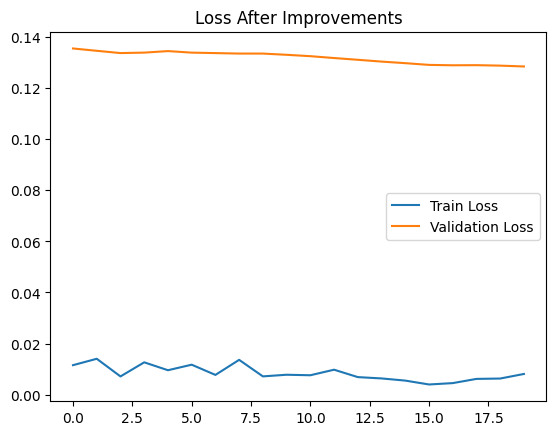

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss After Improvements")
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[69  0  1  1]
 [ 0 76  0  1]
 [ 2  0 76  1]
 [ 0  2  1 90]]


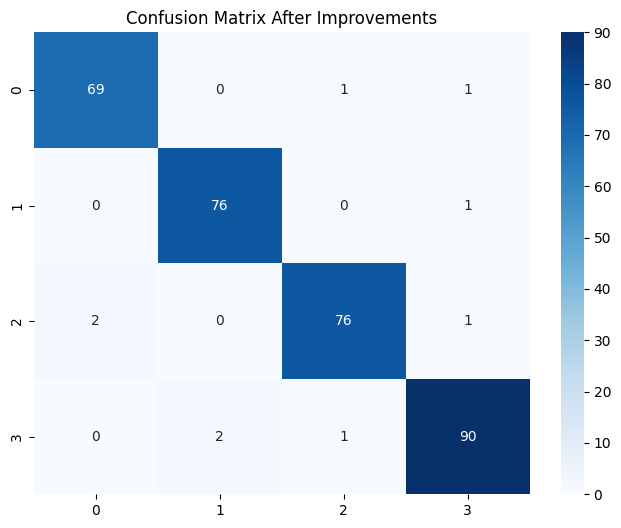

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix After Improvements")
plt.show()